# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

#### Who (The Decision-Maker or Stakeholder)

- Real estate investors looking to buy properties in Austin, TX for rental or resale.
- Homeowners considering listing their property on Airbnb to generate income.
- Real estate agents and analysts looking for insights into market trends.
- Urban planners and policymakers interested in understanding short-term rental impacts.

#### What (The Decision to Be Made)

- Whether to invest in a property for short-term rental (Airbnb) or long-term resale.
- Identifying undervalued properties with high potential for appreciation or rental income.
- Predicting future property values based on features like size, location, and historical price trends.
- Determining key factors that influence Airbnb pricing and occupancy rates.
- Comparing Austin’s real estate market to national trends to identify investment opportunities.

#### How (The Data and Techniques Used to Support the Decision)
- Supervised Learning: Using regression models to predict property prices and potential Airbnb income.
- Unsupervised Learning: Applying clustering techniques (e.g., K-means) to group similar properties and identify patterns.
- Feature Engineering: Extracting insights from amenities, location, and text data (descriptions, reviews).
- Geospatial Analysis: Mapping property values and rental demand across different Austin neighborhoods.
- Comparative Analysis: Cross-referencing traditional home sales with Airbnb profitability metrics to determine the best investment strategy.

# 3. Homework - work with your own data

In [1148]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

This is the dataset on Real Estate. Can be found on https://www.kaggle.com/datasets/ahmedshahriarsakib/usa-real-estate-dataset/data



In [1149]:
import pandas as pd

real_estate_df = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/realtor-data.zip.csv")

In [1150]:
real_estate_df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


In [1151]:
# Summarizing the data using info() and describe()

real_estate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          object 
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            object 
 8   state           object 
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  object 
dtypes: float64(8), object(4)
memory usage: 203.8+ MB


In [1152]:
real_estate_df.describe()

,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,2.221849e+06,2.224841e+06,1.745065e+06,1.714611e+06,1.900793e+06,2.215516e+06,2.226083e+06,1.657898e+06
mean,5.293989e+04,5.241955e+05,3.275841e+00,2.496440e+00,1.522303e+01,1.012325e+06,5.218668e+04,2.714471e+03
std,3.064275e+04,2.138893e+06,1.567274e+00,1.652573e+00,7.628238e+02,5.837635e+05,2.895408e+04,8.081635e+05
min,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
25%,2.386100e+04,1.650000e+05,3.000000e+00,2.000000e+00,1.500000e-01,5.063128e+05,2.961700e+04,1.300000e+03
50%,5.288400e+04,3.250000e+05,3.000000e+00,2.000000e+00,2.600000e-01,1.012766e+06,4.838200e+04,1.760000e+03
75%,7.918300e+04,5.500000e+05,4.000000e+00,3.000000e+00,9.800000e-01,1.521173e+06,7.807000e+04,2.413000e+03
max,1.101420e+05,2.147484e+09,4.730000e+02,8.300000e+02,1.000000e+05,2.001357e+06,9.999900e+04,1.040400e+09


In [1153]:
# Mean
print("Mean:\n", real_estate_df.mean(numeric_only=True))

# Median
print("\nMedian:\n", real_estate_df.median(numeric_only=True))

# Mode
print("\nMode:\n", real_estate_df.mode(numeric_only=True).iloc[0])

Mean:
 brokered_by    5.293989e+04
price          5.241955e+05
bed            3.275841e+00
bath           2.496440e+00
acre_lot       1.522303e+01
street         1.012325e+06
zip_code       5.218668e+04
house_size     2.714471e+03
dtype: float64

Median:
 brokered_by      52884.00
price           325000.00
bed                  3.00
bath                 2.00
acre_lot             0.26
street         1012765.50
zip_code         48382.00
house_size        1760.00
dtype: float64

Mode:
 brokered_by      22611.00
price           350000.00
bed                  3.00
bath                 2.00
acre_lot             0.17
street         1916862.00
zip_code         33993.00
house_size        1200.00
Name: 0, dtype: float64


In [1154]:
# Distinct values
for column in real_estate_df.columns:
    print(f"Distinct values in {column}:")
    print(real_estate_df[column].nunique())  # Count of distinct values
    print(real_estate_df[column].unique())  # List of unique values
    print("\n")

Distinct values in brokered_by:
110143
[103378.  52707. 103379. ...  12005.  76918.  98730.]


Distinct values in status:
3
['for_sale' 'ready_to_build' 'sold']


Distinct values in price:
102137
[105000.  80000.  67000. ... 386464. 488512. 280290.]


Distinct values in bed:
99
[  3.   4.   2.   6.   5.   1.   9.  nan   7.   8.  12.  13.  10.  11.
  33.  24.  28.  14.  18.  20.  16.  15.  19.  17.  40.  21.  86.  31.
  27.  42.  60.  22.  32.  99.  49.  29.  30.  23.  46.  36.  68. 123.
  25.  47.  35.  38.  64.  48.  75. 142.  61.  70.  53.  26.  34.  54.
  71. 210.  66.  44.  37.  62.  72. 100.  55.  74.  73. 473.  52. 110.
 136.  50.  98. 102.  69.  82.  41.  76.  43.  80.  67. 190.  93.  45.
  96.  57.  39.  56.  63.  90. 108. 111. 212.  88. 222. 444. 148.  84.
 114. 120.]


Distinct values in bath:
86
[  2.   1.   3.   5.   4.   7.   6.  nan   8.   9.  10.  12.  13.  35.
  11.  16.  15.  18.  20.  14.  36.  25.  17.  19.  56.  42.  51.  28.
 198.  22.  33.  27.  30.  29.  24.  46.

In [1155]:
real_estate_df.describe(include = 'object')

,status,city,state,prev_sold_date
count,2226382,2224975,2226374,1492085
unique,3,20098,55,14954
top,for_sale,Houston,Florida,2022-03-31
freq,1389306,23862,249432,17171


In [1156]:
# Are there any duplicate rows

real_estate_df.duplicated().sum()

0

The output is 0 so we don't have any duplicate rows.

In [1157]:
# Duplicate street
real_estate_df['street'].duplicated().sum()

225023

In [1158]:
address_counts = real_estate_df.groupby(['street', 'city', 'state', 'zip_code']).size()

# Find duplicate addresses (those appearing more than once)
duplicate_addresses = address_counts[address_counts > 1]

# Getting the first three duplicate addresses
if not duplicate_addresses.empty:
    first_three_duplicates = duplicate_addresses.index[:3]
    print("First three duplicate addresses:")

    for address in first_three_duplicates:
        print(f"\nDuplicate Address: {address}")
        print(real_estate_df.loc[
            (real_estate_df["street"] == address[0]) &
            (real_estate_df["city"] == address[1]) &
            (real_estate_df["state"] == address[2]) &
            (real_estate_df["zip_code"] == address[3])
        ])
else:
    print("No duplicate addresses found.")

First three duplicate addresses:

Duplicate Address: (78.0, 'Audubon', 'Iowa', 50025.0)
         brokered_by    status    price  bed  bath  acre_lot  street     city  \
770262       93465.0  for_sale  20000.0  NaN   NaN      0.61    78.0  Audubon   
1793190      93465.0      sold  20000.0  NaN   NaN      0.61    78.0  Audubon   

        state  zip_code  house_size prev_sold_date  
770262   Iowa   50025.0         NaN            NaN  
1793190  Iowa   50025.0         NaN     2022-04-22  

Duplicate Address: (232.0, 'Weeki Wachee', 'Florida', 34613.0)
         brokered_by status     price  bed  bath  acre_lot  street  \
1744238      41366.0   sold  179000.0  NaN   NaN      15.8   232.0   
1744306      41366.0   sold  159000.0  NaN   NaN      10.0   232.0   

                 city    state  zip_code  house_size prev_sold_date  
1744238  Weeki Wachee  Florida   34613.0         NaN     2022-01-28  
1744306  Weeki Wachee  Florida   34613.0         NaN     2022-02-14  

Duplicate Address: (235

Duplicate values on zip_code, city, state, street is expected, since it means a specific area, and there should be several houses on that area, we can see the acre_lots are different even though same address, indicating diffeent houses on the same address.

We can see that there is information on the same house before being sold and after being sold, hence Duplicate Address: (78.0, 'Audubon', 'Iowa', 50025.0) has all the values same except for status. 

Now we can see on row 770262, NaN value on prev_sold_date, has status for_sale, which can mean this house was never sold before. 

In [1159]:
#changing null values of 'prev_sold_date' column with boolean values
real_estate_df['prev_sold_date'] = real_estate_df['prev_sold_date'].apply(lambda x: 'Yes' if pd.notna(x) else 'No')
real_estate_df['prev_sold_encoded'] = real_estate_df['prev_sold_date'].map({'Yes': 1, 'No': 0})
real_estate_df

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date,prev_sold_encoded
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,No,0
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,No,0
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,No,0
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,No,0
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2226377,23009.0,sold,359900.0,4.0,2.0,0.33,353094.0,Richland,Washington,99354.0,3600.0,Yes,1
2226378,18208.0,sold,350000.0,3.0,2.0,0.10,1062149.0,Richland,Washington,99354.0,1616.0,Yes,1
2226379,76856.0,sold,440000.0,6.0,3.0,0.50,405677.0,Richland,Washington,99354.0,3200.0,Yes,1
2226380,53618.0,sold,179900.0,2.0,1.0,0.09,761379.0,Richland,Washington,99354.0,933.0,Yes,1


In [1160]:
null_df = pd.DataFrame(real_estate_df.isnull().sum(), columns=['Count of Nulls'])
null_df.index.name = 'Column Name'
null_df[ null_df['Count of Nulls'] > 0 ].sort_values('Count of Nulls', ascending=False)

,Count of Nulls
Column Name,
house_size,568484
bath,511771
bed,481317
acre_lot,325589
street,10866
brokered_by,4533
price,1541
city,1407
zip_code,299


In [1161]:
# Filled all null values from bed, bath, acre_lot and house_size with mode values
real_estate_df['bed'].fillna(real_estate_df['bed'].mode()[0], inplace=True)
real_estate_df['bath'].fillna(real_estate_df['bath'].mode()[0], inplace=True)
real_estate_df['acre_lot'].fillna(real_estate_df['acre_lot'].mode()[0], inplace=True)
real_estate_df['house_size'].fillna(real_estate_df['house_size'].mode()[0], inplace=True)

In [1162]:
#drop remaining null values

real_estate_df = real_estate_df.dropna(subset=['zip_code','city', 'price'])

print(real_estate_df.isnull().sum())

brokered_by           4523
status                   0
price                    0
bed                      0
bath                     0
acre_lot                 0
street               10751
city                     0
state                    6
zip_code                 0
house_size               0
prev_sold_date           0
prev_sold_encoded        0
dtype: int64


In [1163]:
# drop street and brokered_by since it is encoded, then commenting it out to avoid errors

real_estate_df = real_estate_df.drop("street", axis = 1)
real_estate_df = real_estate_df.drop("brokered_by", axis = 1)

# Dropping null state rows
real_estate_df = real_estate_df.dropna(subset=['state'])

print(real_estate_df.isnull().sum())

status               0
price                0
bed                  0
bath                 0
acre_lot             0
city                 0
state                0
zip_code             0
house_size           0
prev_sold_date       0
prev_sold_encoded    0
dtype: int64


In [1164]:
try:
    # Changing columns to string type
    real_estate_df['zip_code'] = real_estate_df['zip_code'].astype(str)
    print("It worked!")
except ValueError as e:
    print(f"ValueError for 'zip_code': {e}")

It worked!


In [1165]:
real_estate_df.head()

,status,price,bed,bath,acre_lot,city,state,zip_code,house_size,prev_sold_date,prev_sold_encoded
0,for_sale,105000.0,3.0,2.0,0.12,Adjuntas,Puerto Rico,601.0,920.0,No,0
1,for_sale,80000.0,4.0,2.0,0.08,Adjuntas,Puerto Rico,601.0,1527.0,No,0
2,for_sale,67000.0,2.0,1.0,0.15,Juana Diaz,Puerto Rico,795.0,748.0,No,0
3,for_sale,145000.0,4.0,2.0,0.10,Ponce,Puerto Rico,731.0,1800.0,No,0
4,for_sale,65000.0,6.0,2.0,0.05,Mayaguez,Puerto Rico,680.0,1200.0,No,0


In [1166]:
# Checking for class imbalance in categorical columns
city_counts = real_estate_df['city'].value_counts()

print("Class imbalance in 'city':")
print(city_counts)


Class imbalance in 'city':
Houston                   23861
Chicago                   18218
New York City             12634
Jacksonville              11743
Philadelphia              10449
                          ...  
Torrey Pines Dr Asbury        1
Percival                      1
Little Sioux                  1
Honey Creek                   1
Kahlotus                      1
Name: city, Length: 20069, dtype: int64


1. Major Cities Dominate the Data
Houston (23,861), Chicago (18,218), and New York City (12,634) have the most entries.
These cities represent a large proportion of the dataset, meaning most insights will be driven by these locations.
2. Small Cities & Outliers
Many cities have only 1 entry (e.g., "Torrey Pines Dr Asbury," "Percival," "Little Sioux," etc.).
These cities have extremely limited data, making them unreliable for modeling or statistical insights.

The dataset had a lot of missing values.
Some class imbalance is evident, but a further check on categorical distributions might be necessary.
Fixing column types and potential errors in address data improved usability.

In [1167]:
real_estate_df.to_csv('/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/updated_real_estate.csv', index=False)


This is the 2nd dataset, it's on Austin housing. Can be found on https://www.kaggle.com/datasets/ericpierce/austinhousingprices/data


In [1168]:
austin_df = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/austinHousingData.csv")
austin_df.head()


,zpid,city,streetAddress,zipcode,description,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,...,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories,homeImage
0,111373431,pflugerville,14424 Lake Victor Dr,78660,"14424 Lake Victor Dr, Pflugerville, TX 78660 i...",30.430632,-97.663078,1.98,2,True,...,1,1,1.266667,2.666667,1063,14,3.0,4,2,111373431_ffce26843283d3365c11d81b8e6bdc6f-p_f...
1,120900430,pflugerville,1104 Strickling Dr,78660,Absolutely GORGEOUS 4 Bedroom home with 2 full...,30.432673,-97.661697,1.98,2,True,...,1,1,1.400000,2.666667,1063,14,2.0,4,1,120900430_8255c127be8dcf0a1a18b7563d987088-p_f...
2,2084491383,pflugerville,1408 Fort Dessau Rd,78660,Under construction - estimated completion in A...,30.409748,-97.639771,1.98,0,True,...,1,1,1.200000,3.000000,1108,14,2.0,3,1,2084491383_a2ad649e1a7a098111dcea084a11c855-p_...
3,120901374,pflugerville,1025 Strickling Dr,78660,Absolutely darling one story home in charming ...,30.432112,-97.661659,1.98,2,True,...,1,1,1.400000,2.666667,1063,14,2.0,3,1,120901374_b469367a619da85b1f5ceb69b675d88e-p_f...
4,60134862,pflugerville,15005 Donna Jane Loop,78660,Brimming with appeal & warm livability! Sleek ...,30.437368,-97.656860,1.98,0,True,...,1,1,1.133333,4.000000,1223,14,3.0,3,2,60134862_b1a48a3df3f111e005bb913873e98ce2-p_f.jpg


In [1169]:
columns_to_drop = [
    "zpid", "streetAddress", "homeImage", "latestPriceSource",
    "latitude", "longitude", "hasGarage", 
    "latest_salemonth", "latest_saleyear", "description", "numOfPhotos"
]
austin_df = austin_df.drop(columns=columns_to_drop)

In [1170]:
print(austin_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15171 entries, 0 to 15170
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        15171 non-null  object 
 1   zipcode                     15171 non-null  int64  
 2   propertyTaxRate             15171 non-null  float64
 3   garageSpaces                15171 non-null  int64  
 4   hasAssociation              15171 non-null  bool   
 5   hasCooling                  15171 non-null  bool   
 6   hasHeating                  15171 non-null  bool   
 7   hasSpa                      15171 non-null  bool   
 8   hasView                     15171 non-null  bool   
 9   homeType                    15171 non-null  object 
 10  parkingSpaces               15171 non-null  int64  
 11  yearBuilt                   15171 non-null  int64  
 12  latestPrice                 15171 non-null  float64
 13  numPriceChanges             151

In [1171]:

print(austin_df.describe())


            zipcode  propertyTaxRate  garageSpaces  parkingSpaces  \
count  15171.000000     15171.000000  15171.000000   15171.000000   
mean   78735.932964         1.994085      1.229187       1.224507   
std       18.893475         0.053102      1.352117       1.352732   
min    78617.000000         1.980000      0.000000       0.000000   
25%    78727.000000         1.980000      0.000000       0.000000   
50%    78739.000000         1.980000      1.000000       1.000000   
75%    78749.000000         1.980000      2.000000       2.000000   
max    78759.000000         2.210000     22.000000      22.000000   

          yearBuilt   latestPrice  numPriceChanges  \
count  15171.000000  1.517100e+04     15171.000000   
mean    1988.554743  5.127677e+05         3.032892   
std       21.579458  4.531853e+05         2.487392   
min     1905.000000  5.500000e+03         1.000000   
25%     1974.000000  3.090000e+05         1.000000   
50%     1993.000000  4.050000e+05         2.000000   


In [1172]:
print(f"Austin dataset duplicate rows: {austin_df.duplicated().sum()}")

Austin dataset duplicate rows: 0


Output is 0, so no duplicate rows.

In [1173]:
missing_values = austin_df.isnull().sum()
print("Missing values in each column:")
print(missing_values)


Missing values in each column:
city                          0
zipcode                       0
propertyTaxRate               0
garageSpaces                  0
hasAssociation                0
hasCooling                    0
hasHeating                    0
hasSpa                        0
hasView                       0
homeType                      0
parkingSpaces                 0
yearBuilt                     0
latestPrice                   0
numPriceChanges               0
latest_saledate               0
numOfAccessibilityFeatures    0
numOfAppliances               0
numOfParkingFeatures          0
numOfPatioAndPorchFeatures    0
numOfSecurityFeatures         0
numOfWaterfrontFeatures       0
numOfWindowFeatures           0
numOfCommunityFeatures        0
lotSizeSqFt                   0
livingAreaSqFt                0
numOfPrimarySchools           0
numOfElementarySchools        0
numOfMiddleSchools            0
numOfHighSchools              0
avgSchoolDistance             0
avgSchool

We can see there are no missing values.


In [1174]:
# Checking for inconsistent values like negative prices or incorrect year built
inconsistent_data_price = austin_df[austin_df['latestPrice'] <= 0]
print("Inconsistent data (prices <= 0):")
print(inconsistent_data_price)

inconsistent_data_year = austin_df[austin_df['yearBuilt'] > 2026]
print("Inconsistent data (homes built after 2026):")
print(inconsistent_data_year['yearBuilt'])

Inconsistent data (prices <= 0):
Empty DataFrame
Columns: [city, zipcode, propertyTaxRate, garageSpaces, hasAssociation, hasCooling, hasHeating, hasSpa, hasView, homeType, parkingSpaces, yearBuilt, latestPrice, numPriceChanges, latest_saledate, numOfAccessibilityFeatures, numOfAppliances, numOfParkingFeatures, numOfPatioAndPorchFeatures, numOfSecurityFeatures, numOfWaterfrontFeatures, numOfWindowFeatures, numOfCommunityFeatures, lotSizeSqFt, livingAreaSqFt, numOfPrimarySchools, numOfElementarySchools, numOfMiddleSchools, numOfHighSchools, avgSchoolDistance, avgSchoolRating, avgSchoolSize, MedianStudentsPerTeacher, numOfBathrooms, numOfBedrooms, numOfStories]
Index: []

[0 rows x 36 columns]
Inconsistent data (homes built after 2026):
Series([], Name: yearBuilt, dtype: int64)


In [1175]:
# One-hot encode the categorical variables 'homeType'
austin_df_encoded = pd.get_dummies(austin_df, columns=['homeType'], drop_first=True)
austin_df_encoded.head()

,city,zipcode,propertyTaxRate,garageSpaces,hasAssociation,hasCooling,hasHeating,hasSpa,hasView,parkingSpaces,...,numOfStories,homeType_Condo,homeType_Mobile / Manufactured,homeType_MultiFamily,homeType_Multiple Occupancy,homeType_Other,homeType_Residential,homeType_Single Family,homeType_Townhouse,homeType_Vacant Land
0,pflugerville,78660,1.98,2,True,True,True,False,False,2,...,2,0,0,0,0,0,0,1,0,0
1,pflugerville,78660,1.98,2,True,True,True,False,False,2,...,1,0,0,0,0,0,0,1,0,0
2,pflugerville,78660,1.98,0,True,True,True,False,False,0,...,1,0,0,0,0,0,0,1,0,0
3,pflugerville,78660,1.98,2,True,True,True,False,False,2,...,1,0,0,0,0,0,0,1,0,0
4,pflugerville,78660,1.98,0,True,True,True,False,False,0,...,2,0,0,0,0,0,0,1,0,0


In [1176]:
# Checking for class imbalance in categorical columns
city_counts = austin_df['city'].value_counts()
home_type_counts = austin_df['homeType'].value_counts()

print("Class imbalance in 'city':")
print(city_counts)

print("\nClass imbalance in 'homeType':")
print(home_type_counts)

Class imbalance in 'city':
austin              15020
del valle              86
pflugerville           36
driftwood              12
manor                   6
dripping springs        5
manchaca                3
west lake hills         2
road                    1
Name: city, dtype: int64

Class imbalance in 'homeType':
Single Family            14241
Condo                      470
Townhouse                  174
Multiple Occupancy          96
Vacant Land                 83
Residential                 37
Apartment                   37
Mobile / Manufactured       17
MultiFamily                 10
Other                        6
Name: homeType, dtype: int64


1. Class Imbalance in the 'city' Column
The distribution of city values shows a strong imbalance:

Austin has 15,020 properties, making up the overwhelming majority.
Other cities like Del Valle (86) and Pflugerville (36) have very few properties.
Some cities, like West Lake Hills (2) and Road (1), have almost no representation.

2. Class Imbalance in the 'homeType' Column
The homeType column is also highly imbalanced:

Single Family homes (14,241) dominate the dataset.
Other types like Condos (470), Townhouses (174), and Multiple Occupancy (96) are much smaller in number.
Categories such as MultiFamily (10) and Other (6) have very few entries.

Data is quite usable. There were not any null or duplicate value, means data was already pretty clean for further analysis.

In [1177]:
austin_df_encoded.to_csv('/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/cleaned_austin_data.csv', index=False)


This is the 3rd dataset on Airbnb found from here: https://insideairbnb.com/get-the-data/


In [1178]:
airbnb_df = pd.read_csv("/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/Arvinds datasets/listingsForVisualization.csv")
airbnb_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,27262,"AQA-No7, Great mattress, high speed internet",37177,Emmanouil,NaN,ΑΜΠΕΛΟΚΗΠΟΙ,37.98924,23.76500,Entire home/apt,131.0,1,29,2024-11-18,0.19,1,355,5,00002433111
1,33945,Spacious Cosy aprtm very close to Metro!,146553,Katerina,NaN,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,38.00673,23.72775,Entire home/apt,47.0,4,78,2024-11-11,0.45,2,361,9,00000874421
2,49489,Ermou 44 - 3bdr apt in the heart of Athens,225612,Stathis,NaN,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,37.97670,23.73064,Entire home/apt,200.0,2,140,2024-07-14,0.86,1,354,4,00000876484
3,60394,Cosy apartment! Great central Athens location!,290864,Dimitra,NaN,ΣΤΑΔΙΟ,37.96738,23.74038,Entire home/apt,50.0,6,34,2024-11-02,0.29,1,180,4,01039140005
4,133835,Studio in upscale/central location,656936,Elena,NaN,ΚΟΛΩΝΑΚΙ,37.97794,23.74371,Entire home/apt,55.0,3,27,2024-09-15,0.17,1,357,6,00001227000


In [1179]:
airbnb_df.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,1.464200e+04,1.464200e+04,0.0,14642.000000,14642.000000,13722.000000,14642.000000,14642.000000,12329.000000,14642.000000,14642.000000,14642.000000
mean,6.438408e+17,2.616415e+08,NaN,37.979781,23.731569,105.081839,2.666029,53.057984,1.728401,14.233438,254.583868,13.841825
std,5.144700e+17,2.031314e+08,NaN,0.013238,0.012316,306.535658,11.966557,93.138746,1.715897,22.290716,111.715578,19.476072
min,2.726200e+04,1.805000e+03,NaN,37.950322,23.700809,10.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,4.121628e+07,7.314389e+07,NaN,37.968701,23.724068,48.000000,1.000000,2.000000,0.430000,1.000000,179.000000,0.000000
50%,8.288510e+17,2.120277e+08,NaN,37.978400,23.729730,69.000000,2.000000,14.000000,1.110000,4.000000,290.000000,5.000000
75%,1.118030e+18,4.646603e+08,NaN,37.987470,23.737219,106.000000,2.000000,58.000000,2.530000,16.000000,351.000000,20.000000
max,1.318602e+18,6.683661e+08,NaN,38.030830,23.780220,15200.000000,639.000000,966.000000,11.400000,125.000000,365.000000,165.000000


In [1180]:
#checking duplicate rows

duplicate_rows = airbnb_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


In [1181]:
# Checking for Duplicate Values in Specific Columns

duplicate_ids = airbnb_df['id'].duplicated().sum()
duplicate_licenses = airbnb_df['license'].duplicated().sum()

print(f"Duplicate IDs: {duplicate_ids}")
print(f"Duplicate Licenses: {duplicate_licenses}")

Duplicate IDs: 0
Duplicate Licenses: 1779


In [1182]:
#Calculating Mean, Median, and Mode

mean_values = airbnb_df.mean(numeric_only=True)
median_values = airbnb_df.median(numeric_only=True)
mode_values = airbnb_df.mode().iloc[0]

print("Mean:\n", mean_values)
print("Median:\n", median_values)
print("Mode:\n", mode_values)

Mean:
 id                                6.438408e+17
host_id                           2.616415e+08
neighbourhood_group                        NaN
latitude                          3.797978e+01
longitude                         2.373157e+01
price                             1.050818e+02
minimum_nights                    2.666029e+00
number_of_reviews                 5.305798e+01
reviews_per_month                 1.728401e+00
calculated_host_listings_count    1.423344e+01
availability_365                  2.545839e+02
number_of_reviews_ltm             1.384182e+01
dtype: float64
Median:
 id                                8.288510e+17
host_id                           2.120277e+08
neighbourhood_group                        NaN
latitude                          3.797840e+01
longitude                         2.372973e+01
price                             6.900000e+01
minimum_nights                    2.000000e+00
number_of_reviews                 1.400000e+01
reviews_per_month            

In [1183]:
# Identifying Missing or Null Values

missing_values = airbnb_df.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group               14642
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                               920
minimum_nights                        0
number_of_reviews                     0
last_review                        2313
reviews_per_month                  2313
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                             194
dtype: int64


In [1184]:
#dropping neighbourhood_group column

airbnb_df.drop(columns=['neighbourhood_group'], inplace=True)

In [1185]:
# filling null price and reviews_per_month values

airbnb_df['price'].fillna(airbnb_df['price'].median(), inplace=True)
airbnb_df['reviews_per_month'].fillna(airbnb_df['reviews_per_month'].median(), inplace=True)

In [1186]:
#dropping rows with missing license
airbnb_df.dropna(subset=['license'], inplace=True)

In [1187]:
# inconsistent data

inconsistent_data = airbnb_df[(airbnb_df['minimum_nights'] < 0) | (airbnb_df['availability_365'] > 365)]
print(inconsistent_data)

Empty DataFrame
Columns: [id, name, host_id, host_name, neighbourhood, latitude, longitude, room_type, price, minimum_nights, number_of_reviews, last_review, reviews_per_month, calculated_host_listings_count, availability_365, number_of_reviews_ltm, license]
Index: []


In [1188]:
print(airbnb_df.columns)

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood', 'latitude',
       'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'number_of_reviews_ltm', 'license'],
      dtype='object')


In [1189]:
#performing one hot encoidng

airbnb_encoded = pd.get_dummies(airbnb_df['room_type'], prefix='room_type')
airbnb_df = pd.concat([airbnb_df, airbnb_encoded], axis=1)


# Display the first few rows to verify
airbnb_df.head()



,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,27262,"AQA-No7, Great mattress, high speed internet",37177,Emmanouil,ΑΜΠΕΛΟΚΗΠΟΙ,37.98924,23.76500,Entire home/apt,131.0,1,...,2024-11-18,0.19,1,355,5,00002433111,1,0,0,0
1,33945,Spacious Cosy aprtm very close to Metro!,146553,Katerina,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,38.00673,23.72775,Entire home/apt,47.0,4,...,2024-11-11,0.45,2,361,9,00000874421,1,0,0,0
2,49489,Ermou 44 - 3bdr apt in the heart of Athens,225612,Stathis,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,37.97670,23.73064,Entire home/apt,200.0,2,...,2024-07-14,0.86,1,354,4,00000876484,1,0,0,0
3,60394,Cosy apartment! Great central Athens location!,290864,Dimitra,ΣΤΑΔΙΟ,37.96738,23.74038,Entire home/apt,50.0,6,...,2024-11-02,0.29,1,180,4,01039140005,1,0,0,0
4,133835,Studio in upscale/central location,656936,Elena,ΚΟΛΩΝΑΚΙ,37.97794,23.74371,Entire home/apt,55.0,3,...,2024-09-15,0.17,1,357,6,00001227000,1,0,0,0


In [1190]:
# checking class imbalance

print(airbnb_df['room_type'].value_counts())

Entire home/apt    13345
Private room        1034
Hotel room            58
Shared room           11
Name: room_type, dtype: int64


There is a severe class imbalance, where:

Entire home/apt" dominates (92.7%), making it the majority class.
Other categories (especially "Hotel room" & "Shared room") have very few samples.

Yes, the data is usable, but it requires some modification and cleaning:

The dataset is large and rich, with many valuable features. 

After filling missing values and removing irrelevant columns, the data can be used for analysis and machine learning tasks.

Several modifications have been done to make the data usable for further analysis.

In [1191]:
airbnb_df.to_csv('/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/cleaned_airbnb_data.csv', index=False)


# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

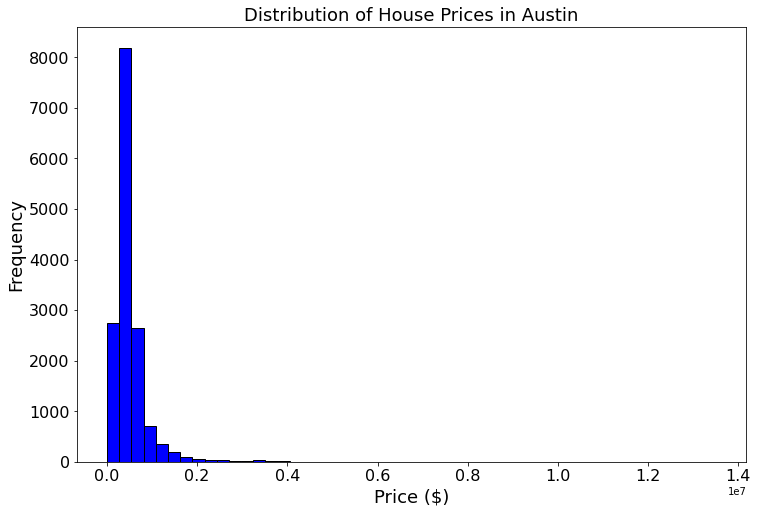

In [1192]:
import matplotlib.pyplot as plt

# Plot histogram for the house prices
plt.figure(figsize=(12, 8))
plt.hist(austin_df['latestPrice'], bins=50, color='blue', edgecolor='black')
plt.xlabel('Price ($)', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.title('Distribution of House Prices in Austin', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

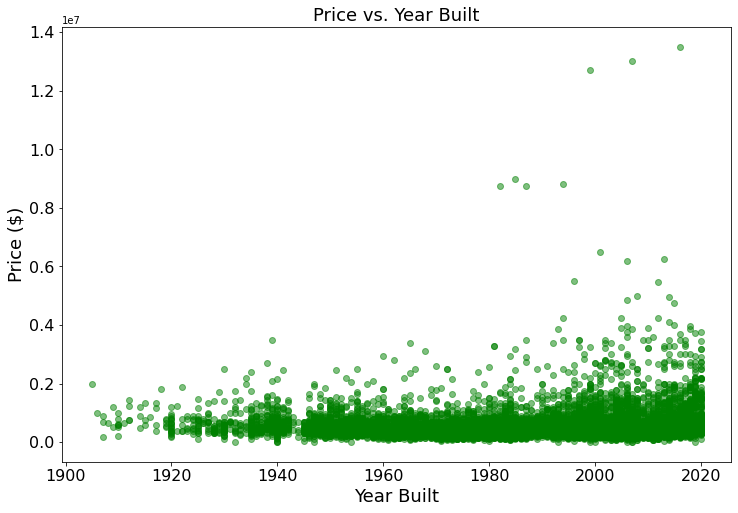

In [1193]:
# Scatter plot for price vs. year built
plt.figure(figsize=(12, 8))
plt.scatter(austin_df['yearBuilt'], austin_df['latestPrice'], alpha=0.5, color='green')
plt.xlabel('Year Built', fontsize=18)
plt.ylabel('Price ($)', fontsize=18)
plt.title('Price vs. Year Built', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()